In [1]:
import os
os.listdir()



['.ipynb_checkpoints', 'student_performance.csv', 'Untitled.ipynb']

In [2]:
import pandas as pd

df = pd.read_csv("student_performance.csv")   
df.head()


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [3]:
df.shape


(1000000, 6)

In [4]:
df.info


<bound method DataFrame.info of         student_id  weekly_self_study_hours  attendance_percentage  \
0                1                     18.5                   95.6   
1                2                     14.0                   80.0   
2                3                     19.5                   86.3   
3                4                     25.7                   70.2   
4                5                     13.4                   81.9   
...            ...                      ...                    ...   
999995      999996                     18.0                   95.5   
999996      999997                     15.7                   82.7   
999997      999998                     14.2                   85.1   
999998      999999                     25.3                   90.0   
999999     1000000                     18.3                   84.6   

        class_participation  total_score grade  
0                       3.8         97.9     A  
1                       2.5  

In [5]:
df.isnull().sum()

student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

In [ ]:
X = df[["weekly_self_study_hours",
        "attendance_percentage",
        "class_participation"]]

y = df["total_score"]


In [7]:
from sklearn.model_selection import train_test_split
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
from sklearn.linear_model import LinearRegression
df_small = df.sample(10000, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
y_pred = model.predict(X_test)


In [11]:
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
y_pred = model.predict(X_test)


In [13]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 7.161333476729988
R2 Score: 0.6600425865640975


In [14]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor()
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_tree))
print("R2 Score:", r2_score(y_test, y_pred_tree))


MAE: 8.368909803498317
R2 Score: 0.4323972853811281


In [15]:
tree = DecisionTreeRegressor(max_depth=5)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_tree))
print("R2:", r2_score(y_test, y_pred_tree))


MAE: 6.108887769855402
R2: 0.7171229164343269


In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=["number"]).corr(), 
            annot=True, 
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


NameError: name 'plt' is not defined

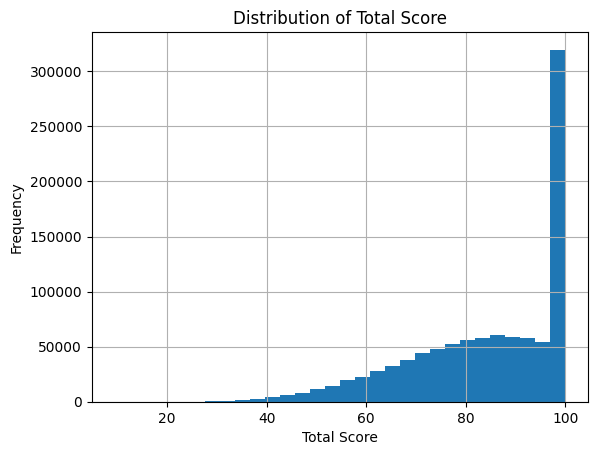

In [ ]:
df["total_score"].hist(bins=30)
plt.title("Distribution of Total Score")
plt.xlabel("Total Score")
plt.ylabel("Frequency")
plt.show()


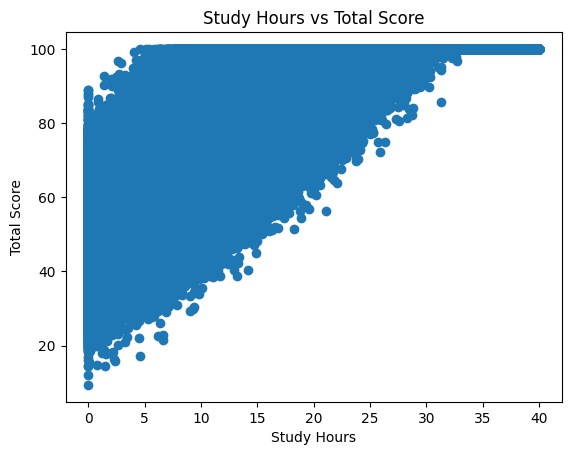

In [ ]:
plt.scatter(df["weekly_self_study_hours"], df["total_score"])
plt.xlabel("Study Hours")
plt.ylabel("Total Score")
plt.title("Study Hours vs Total Score")
plt.show()


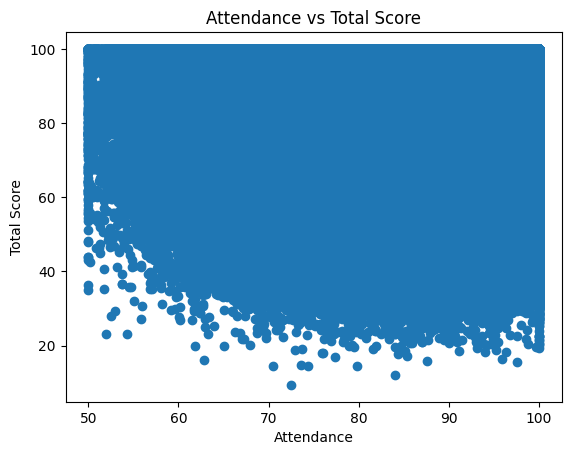

In [ ]:
plt.scatter(df["attendance_percentage"], df["total_score"])
plt.xlabel("Attendance")
plt.ylabel("Total Score")
plt.title("Attendance vs Total Score")
plt.show()


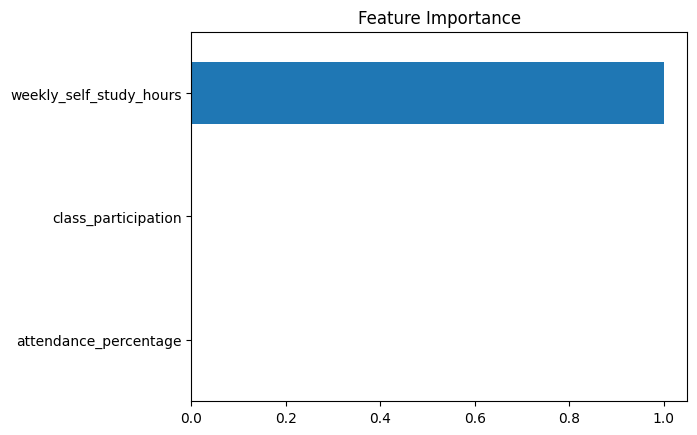

In [ ]:
import pandas as pd

importance = pd.Series(tree.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()


In [ ]:
import pandas as pd

new_student = pd.DataFrame({
    "weekly_self_study_hours": [20],
    "attendance_percentage": [90],
    "class_participation": [6]
})

prediction = model.predict(new_student)
print("Predicted Total Score:", prediction)


Predicted Total Score: [93.30958184]
